In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("data\delhiaqi.csv")

In [4]:
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


In [6]:
df.shape

(561, 9)

In [7]:
df.columns

Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), object(1)
memory usage: 39.6+ KB


In [9]:
df.isnull().sum()

date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

In [11]:
df['date']=pd.to_datetime(df['date'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    561 non-null    datetime64[ns]
 1   co      561 non-null    float64       
 2   no      561 non-null    float64       
 3   no2     561 non-null    float64       
 4   o3      561 non-null    float64       
 5   so2     561 non-null    float64       
 6   pm2_5   561 non-null    float64       
 7   pm10    561 non-null    float64       
 8   nh3     561 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 39.6 KB


In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['year'] = df['date'].dt.year

In [16]:
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour

In [17]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['season'] = df['month'].apply(get_season)

In [18]:
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,year,month,day,hour,season
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83,2023,1,1,0,Winter
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66,2023,1,1,1,Winter
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40,2023,1,1,2,Winter
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55,2023,1,1,3,Winter
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19,2023,1,1,4,Winter


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


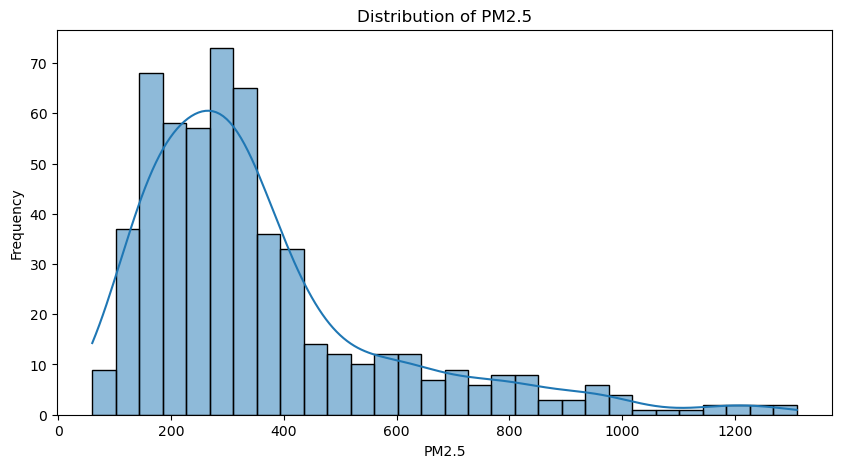

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(df['pm2_5'], bins=30, kde=True)

plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.savefig("images/pm25_distribution.png")
plt.show()

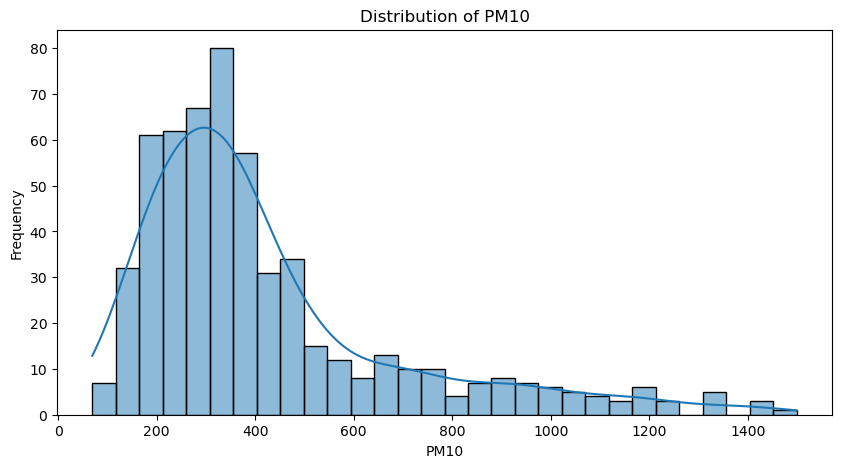

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df['pm10'], bins=30, kde=True)

plt.title("Distribution of PM10")
plt.xlabel("PM10")
plt.ylabel("Frequency")
plt.savefig("images/pm10_distribution.png")
plt.show()

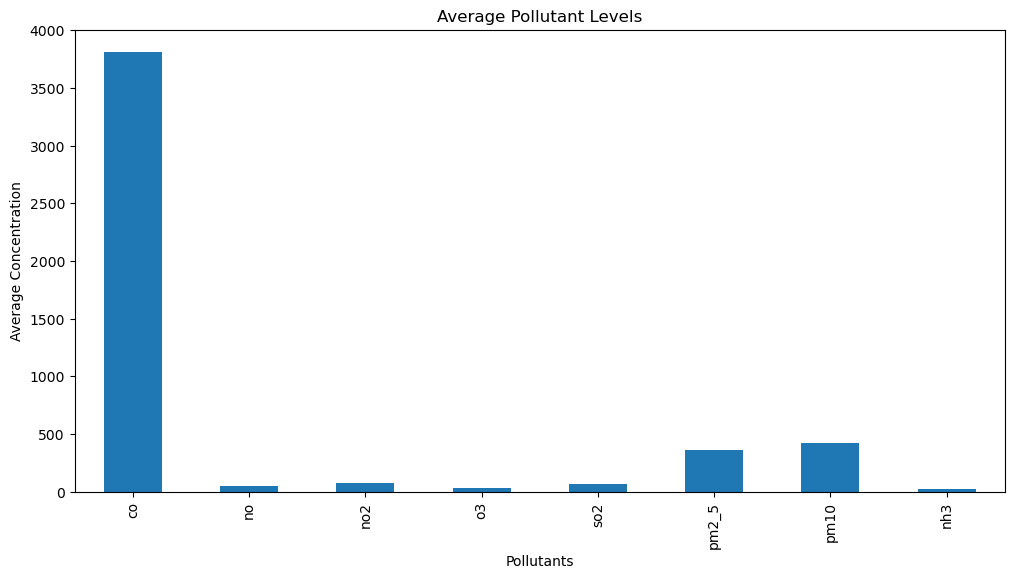

In [22]:
pollutants = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

df[pollutants].mean().plot(kind='bar', figsize=(12,6))

plt.title("Average Pollutant Levels")
plt.xlabel("Pollutants")
plt.ylabel("Average Concentration")
plt.savefig("images/pollutant_comparison ")
plt.show()

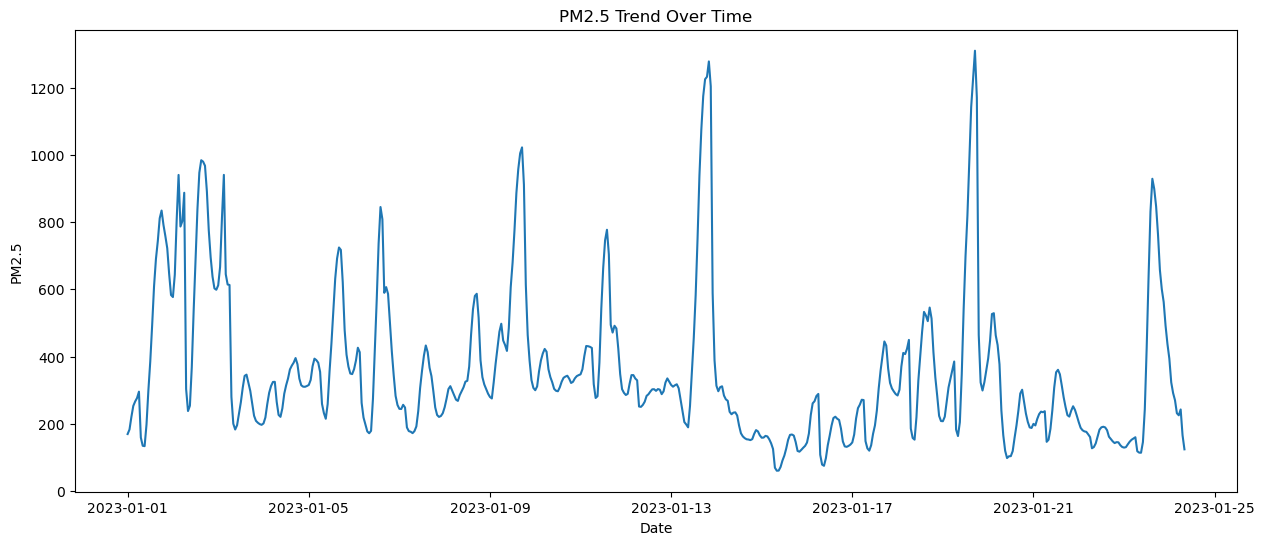

In [23]:
plt.figure(figsize=(15,6))

plt.plot(df['date'], df['pm2_5'])

plt.title("PM2.5 Trend Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.show()

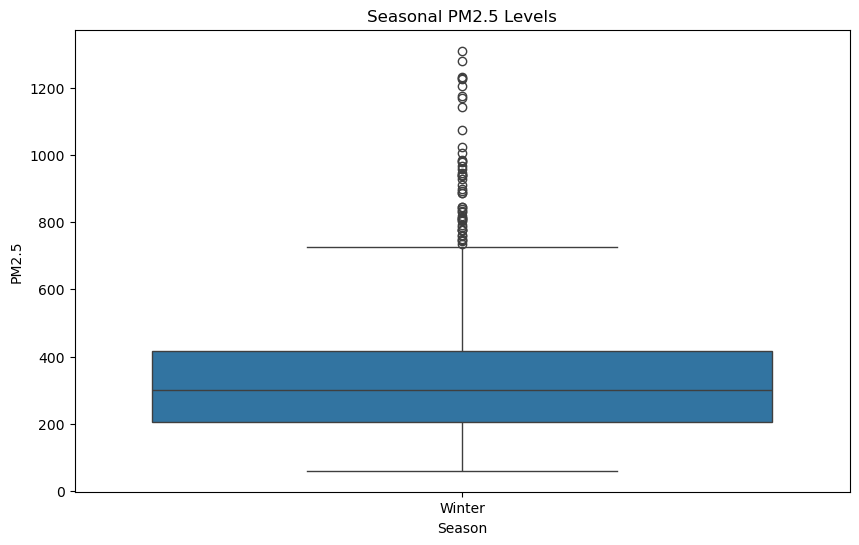

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(x='season', y='pm2_5', data=df)

plt.title("Seasonal PM2.5 Levels")
plt.xlabel("Season")
plt.ylabel("PM2.5")
plt.savefig("images/seasonal_analysis.png")
plt.show()

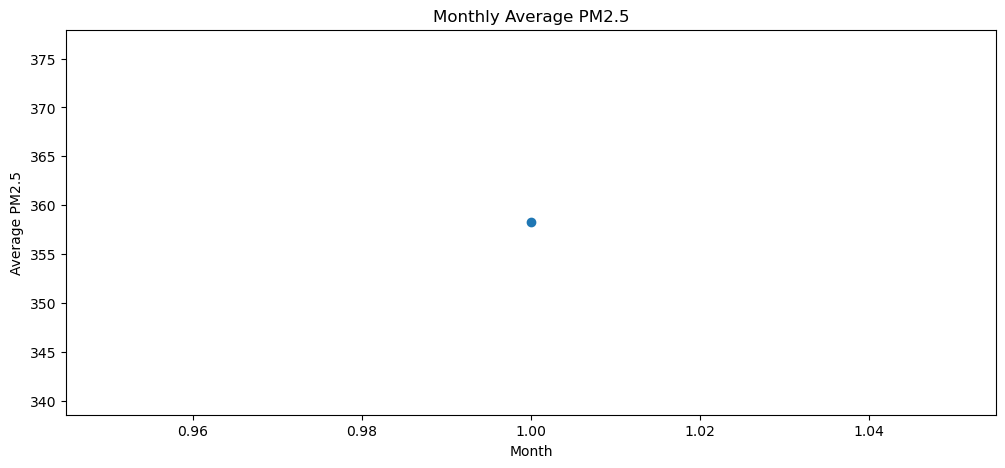

In [25]:
monthly_pm25 = df.groupby('month')['pm2_5'].mean()

monthly_pm25.plot(kind='line', figsize=(12,5), marker='o')

plt.title("Monthly Average PM2.5")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.savefig("images/monthly_trend.png")
plt.show()

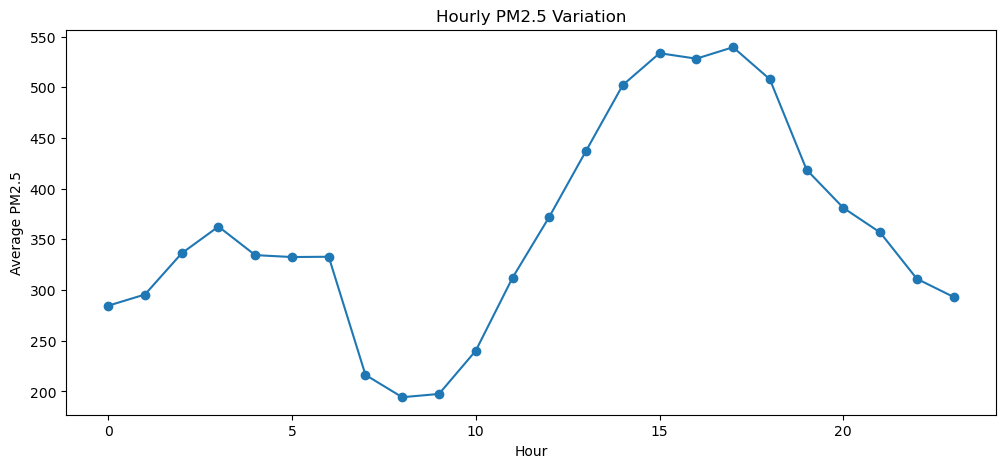

In [26]:
hourly_pm25 = df.groupby('hour')['pm2_5'].mean()

hourly_pm25.plot(kind='line', figsize=(12,5), marker='o')

plt.title("Hourly PM2.5 Variation")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5")
plt.savefig("images/hourly_trend.png")
plt.show()

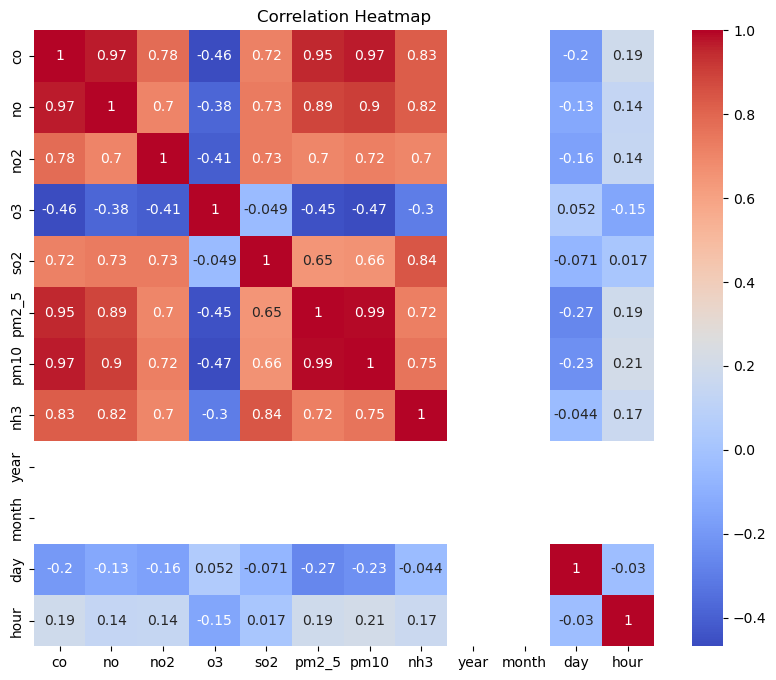

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.savefig("images/heatmap")
plt.show()

In [28]:
seasonal_avg = df.groupby('season')[['pm2_5', 'pm10']].mean()

print(seasonal_avg)

             pm2_5        pm10
season                        
Winter  358.256364  420.988414


## Result

The analysis showed very high PM2.5 and PM10 levels during winter conditions, indicating severe particulate pollution.

In [29]:
monthly_avg = df.groupby('month')[['pm2_5', 'pm10']].mean()

print(monthly_avg)

            pm2_5        pm10
month                        
1      358.256364  420.988414


## Result

The monthly analysis showed variation in pollution levels over time, with higher particulate concentration observed during colder periods.

In [30]:
hourly_avg = df.groupby('hour')[['pm2_5']].mean()

print(hourly_avg)

           pm2_5
hour            
0     284.571250
1     295.627083
2     336.278750
3     362.630417
4     334.481667
5     332.568750
6     332.872500
7     216.307917
8     194.313750
9     197.552609
10    240.183478
11    312.113913
12    372.226087
13    437.294348
14    502.223043
15    533.620870
16    528.229565
17    539.517826
18    507.915652
19    418.675217
20    381.065652
21    356.821739
22    311.110870
23    293.195652


## Result

Hourly analysis indicated fluctuations in PM2.5 concentration throughout the day, likely influenced by traffic and urban activity.

In [32]:
correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

             co        no       no2        o3       so2     pm2_5      pm10  \
co     1.000000  0.969740  0.776402 -0.463082  0.716831  0.953083  0.966801   
no     0.969740  1.000000  0.702201 -0.377813  0.734503  0.888810  0.903339   
no2    0.776402  0.702201  1.000000 -0.407177  0.734961  0.698696  0.720050   
o3    -0.463082 -0.377813 -0.407177  1.000000 -0.049158 -0.450458 -0.468477   
so2    0.716831  0.734503  0.734961 -0.049158  1.000000  0.648996  0.658325   
pm2_5  0.953083  0.888810  0.698696 -0.450458  0.648996  1.000000  0.994088   
pm10   0.966801  0.903339  0.720050 -0.468477  0.658325  0.994088  1.000000   
nh3    0.826299  0.823638  0.700254 -0.299663  0.843635  0.720303  0.754468   
year        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
month       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
day   -0.196306 -0.131474 -0.162382  0.051575 -0.070568 -0.265522 -0.229061   
hour   0.191138  0.135450  0.139751 -0.147007  0.016

## Result

Correlation analysis revealed relationships between multiple pollutants, indicating interconnected pollution sources.

In [33]:
print(correlation_matrix['pm2_5'].sort_values(ascending=False))

pm2_5    1.000000
pm10     0.994088
co       0.953083
no       0.888810
nh3      0.720303
no2      0.698696
so2      0.648996
hour     0.191102
day     -0.265522
o3      -0.450458
year          NaN
month         NaN
Name: pm2_5, dtype: float64


## Result

PM10 showed strong positive correlation with PM2.5, suggesting that particulate pollutants increase together.

In [34]:
high_pollution = df[df['pm2_5'] > 300]

print(high_pollution[['date', 'pm2_5']].head())

                  date   pm2_5
12 2023-01-01 12:00:00  385.41
13 2023-01-01 13:00:00  493.18
14 2023-01-01 14:00:00  608.62
15 2023-01-01 15:00:00  689.94
16 2023-01-01 16:00:00  743.91


## Result

Several observations recorded extremely high PM2.5 levels, indicating severe pollution events and potential health risks.

In [35]:
summary_statistics = df[['pm2_5', 'pm10', 'no2', 'so2']].describe()

print(summary_statistics)

             pm2_5         pm10         no2         so2
count   561.000000   561.000000  561.000000  561.000000
mean    358.256364   420.988414   75.292496   64.655936
std     227.359117   271.287026   42.473791   61.073080
min      60.100000    69.080000   13.370000    5.250000
25%     204.450000   240.900000   44.550000   28.130000
50%     301.170000   340.900000   63.750000   47.210000
75%     416.650000   482.570000   97.330000   77.250000
max    1310.200000  1499.270000  263.210000  511.170000


## Result

The statistical summary provided information about pollutant distribution, variability, and concentration ranges in the dataset.

# Key Findings

- PM2.5 and PM10 were identified as the dominant pollutants.
- Winter conditions showed extremely high particulate pollution levels.
- Strong positive correlation existed between PM2.5 and PM10.
- Pollution concentration varied across different hours and months.
- Several severe pollution events were observed in the dataset.

# Conclusion

The analysis revealed severe particulate pollution levels in Delhi, especially during winter conditions. PM2.5 and PM10 emerged as the major pollutants affecting air quality. The findings highlight the importance of pollution control measures, environmental monitoring, and public health awareness initiatives.